In [85]:
from datetime import datetime, timedelta
import torch
from earth2studio.data import GEFS_FX, HRRR, GEFS_FX_721x1440
import os
import io
import tarfile
from pathlib import Path
import numpy as np
import requests
import tqdm


GEFS_SELECT_VARIABLES = [
    "u10m",
    "v10m",
    "t2m",
    "r2m",
    "sp",
    "msl",
    "tcwv",
]

GEFS_VARIABLES = [
    "u1000",
    "u925",
    "u850",
    "u700",
    "u500",
    "u250",
    "v1000",
    "v925",
    "v850",
    "v700",
    "v500",
    "v250",
    "z1000",
    "z925",
    "z850",
    "z700",
    "z500",
    "z200",
    "t1000",
    "t925",
    "t850",
    "t700",
    "t500",
    "t100",
    "r1000",
    "r925",
    "r850",
    "r700",
    "r500",
    "r100",
]

ds_gefs = GEFS_FX(cache=True)
ds_gefs_select = GEFS_FX_721x1440(cache=True, member="gec00")


def fetch_input_gefs(
    time: datetime, lead_time: timedelta, content_dtype: str = "float32"
):
    """Fetch input GEFS data and place into a single numpy array."""
    dtype = np.dtype(getattr(np, content_dtype))
    g = np.array(9.80665, dtype=dtype)  # standard gravity (m/s^2)

    # Fetch high-res select GEFS input data
    select_data = ds_gefs_select(time, lead_time, GEFS_SELECT_VARIABLES).values
    # Crop to bounding box [225, 21, 300, 53]
    select_data = select_data[:, 0, :, 148:277, 900:1201].astype(dtype)
    assert select_data.shape == (1, len(GEFS_SELECT_VARIABLES), 129, 301)

    # Fetch GEFS pressure-level input data
    pressure_data = ds_gefs(time, lead_time, GEFS_VARIABLES)

    # Interpolate to 0.25° grid (keeping your existing approach)
    pressure_data = torch.nn.functional.interpolate(
        torch.as_tensor(pressure_data.values),
        (len(GEFS_VARIABLES), 721, 1440),
        mode="nearest",
    ).numpy()

    # Crop to bounding box [225, 21, 300, 53]
    pressure_data = pressure_data[:, 0, :, 148:277, 900:1201].astype(dtype)
    assert pressure_data.shape == (1, len(GEFS_VARIABLES), 129, 301)

    # Divide all z-levels by g to convert geopotential (m^2/s^2) -> geopotential height (m)
    z_vars = {"z1000", "z925", "z850", "z700", "z500", "z200"}
    z_indices = [i for i, v in enumerate(GEFS_VARIABLES) if v in z_vars]
    pressure_data[:, z_indices, :, :] /= g

    # Create lead time field in 3-hour increments
    lead_hour = (int(lead_time.total_seconds() // (3 * 60 * 60)) * np.ones((1, 1, 129, 301), dtype=dtype))

    input_data = np.concatenate([select_data, pressure_data, lead_hour], axis=1)[None]
    return input_data

In [171]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature


lats = np.load("corrdiff_output_lat.npy")
lons = np.load("corrdiff_output_lon.npy")
lons = lons - 360


## Use a function to find the location of each station 

In [161]:
def find_nearest(lons, lats, target_lon, target_lat):
    dist = np.sqrt((lons - target_lon)**2 + (lats - target_lat)**2)
    iy, ix = np.unravel_index(np.argmin(dist), dist.shape)
    print(f"Target: ({target_lat}, {target_lon}) → "
          f"Nearest: ({lats[iy,ix]:.4f}, {lons[iy,ix]:.4f}) → "
          f"Index: ({iy}, {ix})")
    return iy, ix

# Find nearest grid points using exact station coordinates
iy_CC83SSE,  ix_CC83SSE  = find_nearest(lons, lats, -97.23969,  27.59483)
iy_CC90SSE,  ix_CC90SSE  = find_nearest(lons, lats, -97.224739, 27.590507)
iy_CC48W,    ix_CC48W    = find_nearest(lons, lats, -97.470553, 27.808389)
iy_CCNW,     ix_CCNW     = find_nearest(lons, lats, -97.5055,   27.7793)
iy_CC51WNW,  ix_CC51WNW  = find_nearest(lons, lats, -97.368309, 27.736549)



Target: (27.59483, -97.23969) → Nearest: (27.6074, -97.2359) → Index: (122, 904)
Target: (27.802861, -97.393186) → Nearest: (27.7934, -97.3852) → Index: (129, 899)
Target: (27.590507, -97.224739) → Nearest: (27.5809, -97.2360) → Index: (121, 904)
Target: (27.808389, -97.470553) → Nearest: (27.8200, -97.4752) → Index: (130, 896)
Target: (27.7793, -97.5055) → Nearest: (27.7669, -97.5052) → Index: (128, 895)
Target: (27.736549, -97.368309) → Nearest: (27.7403, -97.3553) → Index: (127, 900)


## Create a loop that deploys the NIM for each hourly prediction

In [162]:
import io
import tarfile
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
from scipy.ndimage import gaussian_filter

year = 2023
month = 8
day = 22

# Denser 3-hour sampling
Hours = [3, 6, 9, 12, 15, 18, 21, 24]

Total_CC83SSE = []
Total_CC91NW = []
Total_CC90SSE = []
Total_CC48W = []
Total_CCNW = []
Total_CC51WNW = []


for H in Hours:
    print(f"\n{'='*50}")
    print(f"Processing H = {H} hours")
    print(f"{'='*50}\n")

    time = datetime(year, month, day)
    lead_time1 = timedelta(hours=H)
    input_array = fetch_input_gefs(time, lead_time1)

    print(type(input_array), getattr(input_array, "shape", None), getattr(input_array, "dtype", None))
    np.save("corrdiff_inputs.npy", input_array)

    url = "http://corrdiff-nim-service-laurahu:8000/v1/infer"
    files = {
        "input_array": ("input_array", open("corrdiff_inputs.npy", "rb")),
    }
    payload = {
        "samples": 5,
        "steps": 10,
        "seed": 0,
    }
    headers = {
        "accept": "application/x-tar",
    }

    print(f"[H={H:02d}] Sending POST request to NIM ...")
    r = requests.post(url, headers=headers, data=payload, files=files, timeout=3000)
    if r.status_code != 200:
        raise Exception(r.content)
    with open("output.tar", "wb") as tar_file:
        tar_file.write(r.content)
    print(f"[H={H:02d}] Response received.")

    # Ensemble mean over samples
    prec_members = []
    with tarfile.open("output.tar") as tar:
        for member in tar.getmembers():
            buf = io.BytesIO(tar.extractfile(member).read())
            arr = np.load(buf)
            prec_members.append(arr[0, 0, 3])  # tp only

    ensemble_mean = np.mean(prec_members, axis=0) 

    Total_CC83SSE.append(ensemble_mean[iy_CC83SSE,  ix_CC83SSE])
    Total_CC91NW.append( ensemble_mean[iy_CC91NW,   ix_CC91NW])
    Total_CC90SSE.append(ensemble_mean[iy_CC90SSE,  ix_CC90SSE])
    Total_CC48W.append(  ensemble_mean[iy_CC48W,    ix_CC48W])
    Total_CCNW.append(   ensemble_mean[iy_CCNW,     ix_CCNW])
    Total_CC51WNW.append(ensemble_mean[iy_CC51WNW,  ix_CC51WNW])
        
    


Processing H = 3 hours



Fetching GEFS data: 100%|██████████| 7/7 [00:00<00:00, 39.15it/s]


2026-05-19 04:07:38.991 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f003 1706076-738653
2026-05-19 04:07:39.018 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f003 3803061-425978
2026-05-19 04:07:39.043 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f003 6183620-832645
2026-05-19 04:07:39.069 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f003 16961968-None
2026-05-19 04:07:39.095 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f003 4666921-666190
2026-05-19 04:07:39.120 | DEBUG    |

Fetching GEFS data:   0%|          | 0/30 [00:00<?, ?it/s]

2026-05-19 04:07:39.175 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f003 7351648-252795


...

2026-05-19 04:38:54.807 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 5174768-116263


Fetching GEFS data:   0%|          | 0/30 [00:00<?, ?it/s]

2026-05-19 04:38:54.819 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 9616279-274687


Fetching GEFS data: 100%|██████████| 30/30 [00:00<00:00, 80.70it/s]


2026-05-19 04:38:54.831 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 7457684-140073
2026-05-19 04:38:54.843 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 6668273-263973
2026-05-19 04:38:54.855 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 10522778-269343
2026-05-19 04:38:54.866 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 7201514-256170
2026-05-19 04:38:54.878 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 9347134-269145
2026-05-19 04:38:54.890 | DEBUG    | ea

## Saves the results in a dataframe

In [167]:
import pandas as pd

df = pd.DataFrame({
    'Hour':      Hours,
    'CC83SSE':   Total_CC83SSE,
    'CC90SSE':   Total_CC90SSE,
    'CC48W':     Total_CC48W,
    'CCNWS':      Total_CCNW,
    'CC51WNW':   Total_CC51WNW,
})

print(df)
df.to_csv(f"Harold_{month}{day}{year}_precip_stations.csv", index=False)

   Hour   CC83SSE   CC90SSE      CC48W      CCNWS    CC51WNW
0     3 -0.013292  0.003460  -0.014825   0.006016   0.127082
1     6 -0.014302  0.000026  -0.013835  -0.005749   0.036705
2     9  0.661786  1.243148   3.459473   6.467154   3.042323
3    12  3.133021  4.440151  13.722842  22.017752  11.023264
4    15  2.267741  2.443738  10.895948  15.177778   7.613024
5    18  1.645774  0.739081   8.697165  10.187769   6.206809
6    21  2.366165  0.370935  10.512672   8.434624   6.075719
7    24  1.638140  0.203659   7.575534   4.821401   3.972589


## Taking the sum of all stations

In [168]:
Sum_CC83SSE = np.trapz(Total_CC83SSE, dx = 3)
Sum_CC90SSE = np.trapz(Total_CC90SSE, dx = 3)
Sum_CC48W   = np.trapz(Total_CC48W, dx = 3)
Sum_CCNW    = np.trapz(Total_CCNW, dx = 3)
Sum_CC51WNW = np.trapz(Total_CC51WNW, dx = 3)

print(f"CC83SSE: {Sum_CC83SSE:.4f} mm")
print(f"CC90SSE: {Sum_CC90SSE:.4f} mm")
print(f"CC48W:   {Sum_CC48W:.4f} mm")
print(f"CC87SSE: {Sum_CC87SSE:.4f} mm")
print(f"CCNW:    {Sum_CCNW:.4f} mm")
print(f"CC51WNW: {Sum_CC51WNW:.4f} mm")

CC83SSE: 32.6178 mm
CC90SSE: 28.0219 mm
CC48W:   153.1639 mm
CC87SSE: 28.0219 mm
CCNW:    194.0791 mm
CC51WNW: 108.1430 mm


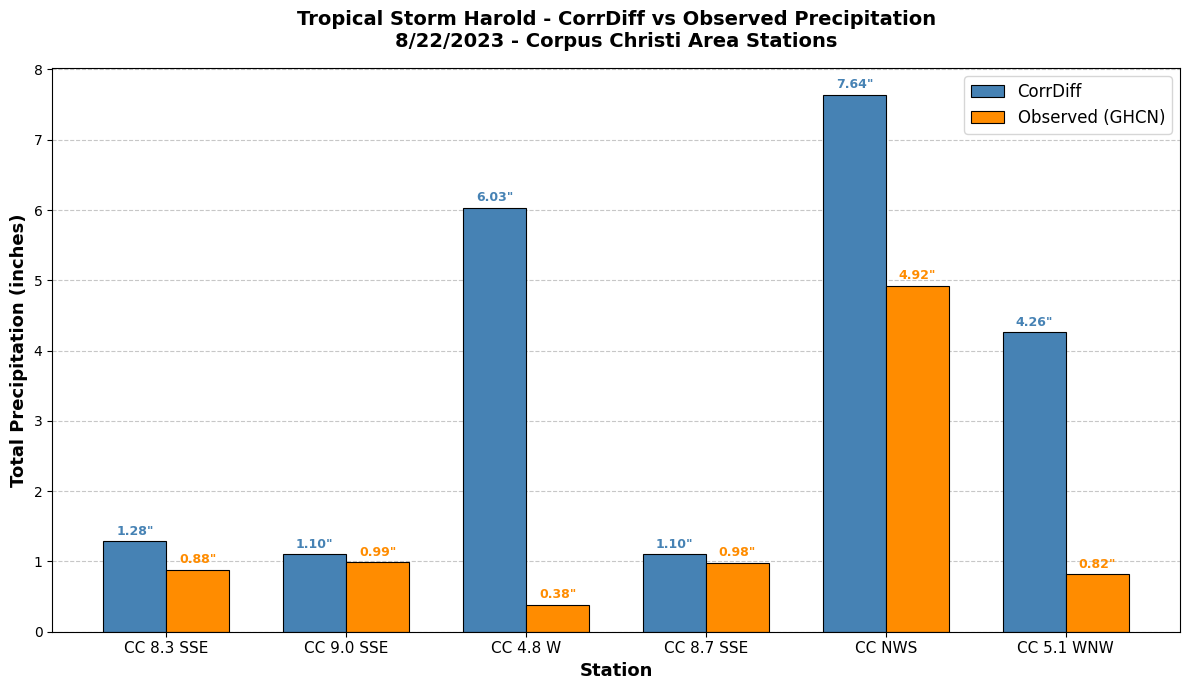

Bar graph saved!


In [170]:
import numpy as np
import matplotlib.pyplot as plt

# Data in mm
stations = ['CC 8.3 SSE', 'CC 9.0 SSE', 'CC 4.8 W', 'CC 8.7 SSE', 'CC NWS', 'CC 5.1 WNW']

corrdiff_mm  = [32.6178, 28.0219, 153.1639, 28.0219, 194.0791, 108.1430]
observed_mm  = [22.4,    25.1,      9.7,    24.9,    125.0,     20.8]

# Convert to inches
corrdiff_in  = [v / 25.4 for v in corrdiff_mm]
observed_in  = [v / 25.4 for v in observed_mm]

x     = np.arange(len(stations))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, corrdiff_in, width, 
               label='CorrDiff', color='steelblue', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, observed_in, width, 
               label='Observed (GHCN)', color='darkorange', edgecolor='black', linewidth=0.8)

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}"', ha='center', va='bottom', 
            fontsize=9, fontweight='bold', color='steelblue')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}"', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='darkorange')

ax.set_xlabel('Station', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Precipitation (inches)', fontsize=13, fontweight='bold')
ax.set_title(f'Tropical Storm Harold - CorrDiff vs Observed Precipitation\n'
             f'{month}/{day}/{year} - Corpus Christi Area Stations',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(stations, fontsize=11)
ax.legend(fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"Harold_{month}{day}{year}_precip_comparison.png", dpi=300)
plt.show()
print("Bar graph saved!")